In [ ]:
import pandas as pd

train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

print(train.head())



   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [10]:
#Question 1:How many passengers survived?

train["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [ ]:
# Step 4: Let's calculate percentages

# Instead of just counts, percentages are often easier to interpret.
train["Survived"].value_counts(normalize=True)


# Instead of returning counts, Pandas returned the proportion (fraction of the total).

# Here's what it calculated:

# Total passengers = 891
# Didn't survive = 549
# Survived = 342

# So Pandas did this internally:

# For passengers who didn't survive:

# 891/549=0.616162

# For passengers who survived:

# 891/342=0.383838

# Converting it to percentages

# A proportion is often easier to understand as a percentage.

# Multiply by 100:

# Value	Proportion	Percentage
# 0	     0.616162	     61.62%
# 1	     0.383838	     38.38%

# So we can say:

# 61.6% of passengers did not survive.
# 38.4% of passengers survived.



Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [16]:

train.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [17]:
train.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [21]:
train.groupby("Embarked")["Survived"].mean()

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

In [ ]:
# | Feature     | Survival Pattern                 | Useful?        |
# | ----------- | -------------------------------- | -------------- |
# | Sex         | Females survived much more often | ⭐⭐⭐⭐⭐ Yes      |
# | Pclass      | First class survived more        | ⭐⭐⭐⭐ Yes       |
# | Embarked    | Cherbourg had higher survival    | ⭐⭐⭐ Maybe      |
# | PassengerId | Just an ID                       | ❌ No           |
# | Name        | Mostly an identifier             | ❌ Probably not |


In [22]:
train["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [23]:
train["Age"].isnull().sum()

np.int64(177)

In [ ]:
train.isnull().sum()


# Which columns need attention?
# 1. Cabin (687 missing)

# This is a huge number.

# Let's calculate the percentage.

# We know there are 891 passengers.

# So:

# 891/687×100≈77%

# That means about 77% of the Cabin values are missing.

# That's a lot!

# 2. Age (177 missing)
# 891/177×100≈20%

# About 20% of passengers have no recorded age.

# That's significant, but still manageable.

# 3. Embarked (2 missing)

# Only:

# 891/2×100≈0.2%

# Almost complete.

# | Column   | Common Strategy                                                                              |
# | -------- | -------------------------------------------------------------------------------------------- |
# | Age      | Fill missing values (often with the median)                                                  |
# | Embarked | Fill the 2 missing values with the most common port                                          |
# | Cabin    | Sometimes drop it because so much data is missing, or extract useful information if possible |


# Raw Data
#     ↓
# Find Missing Values
#     ↓
# Handle Missing Values
#     ↓
# Convert Text to Numbers
#     ↓
# Train Model

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

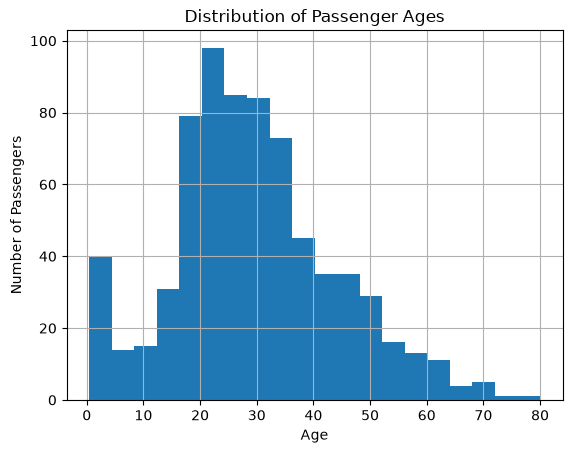

In [26]:
import matplotlib.pyplot as plt

train["Age"].hist(bins=20)

plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

In [27]:
train.groupby("Survived")["Age"].mean()

Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64

In [28]:
df = train.copy()

In [29]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [30]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [31]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [32]:
df["Age"].isnull().sum()

np.int64(0)

In [33]:
df["Age"].describe()

count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64

In [34]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [35]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [36]:
df["Embarked"].mode()

0    S
Name: Embarked, dtype: str

In [37]:
df["Embarked"].isnull().sum()

np.int64(0)

In [38]:
df = df.drop(columns=["Cabin"])

In [39]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='str')

In [40]:
df["Sex"].unique()

<StringArray>
['male', 'female']
Length: 2, dtype: str

In [42]:
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

In [43]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,S


In [44]:
df = pd.get_dummies(
    df,
    columns=["Embarked"],
    drop_first=True
)

In [45]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,False,True


In [49]:
int(True)


1

In [48]:
int(False)

0

In [50]:
drop_first=True

In [ ]:
df = df.drop(columns=["PassengerId", "Name", "Ticket"])

KeyError: "['PassengerId', 'Name', 'Ticket'] not found in axis"

In [55]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


In [58]:
X = df.drop(columns=["Survived"])
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,3,0,22.0,1,0,7.2500,False,True
1,1,1,38.0,1,0,71.2833,False,False
2,3,1,26.0,0,0,7.9250,False,True
3,1,1,35.0,1,0,53.1000,False,True
4,3,0,35.0,0,0,8.0500,False,True


In [59]:
y = df["Survived"]
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [60]:
from sklearn.model_selection import train_test_split

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [62]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 8)
(179, 8)
(712,)
(179,)


In [63]:
from sklearn.tree import DecisionTreeClassifier

In [64]:
model = DecisionTreeClassifier(random_state=42)

In [65]:
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [66]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(by="Importance", ascending=False)

,Feature,Importance
1,Sex,0.310280
5,Fare,0.263543
2,Age,0.206181
0,Pclass,0.111937
3,SibSp,0.059694
4,Parch,0.027496
7,Embarked_S,0.016200
6,Embarked_Q,0.004669


In [67]:
predictions = model.predict(X_test)

In [68]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.7877094972067039


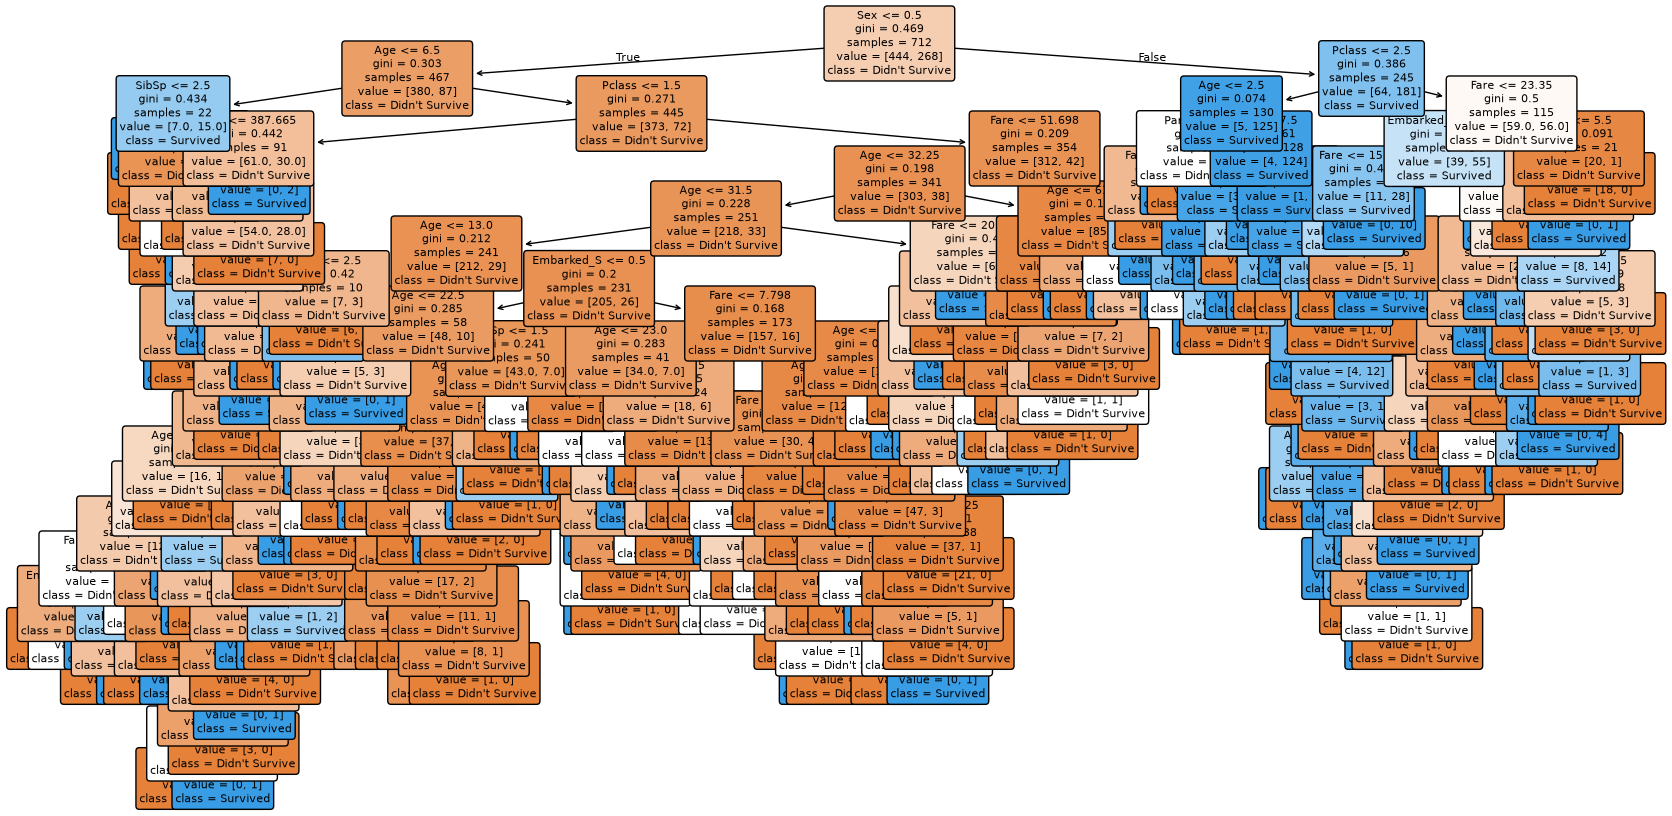

In [ ]:
#Another cool thing: Let's visualize the tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Didn't Survive", "Survived"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

In [70]:
#Load the test data

In [72]:
test = pd.read_csv("../data/test.csv")

test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [73]:
#Check missing values
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [74]:
#Remove Cabin column
test = test.drop(columns=["Cabin"])

In [76]:
#fill missing values for Age
test["Age"] = test["Age"].fillna(test["Age"].median())
#Fill Fare
test["Fare"] = test["Fare"].fillna(test["Fare"].median())
#encode sex
test["Sex"] = test["Sex"].map({
    "male": 0,
    "female": 1
})
#One-Hot Encode Embarked

test = pd.get_dummies(
    test,
    columns=["Embarked"],
    drop_first=True
)

#drop unnecessary columns
test = test.drop(
    columns=["PassengerId", "Name", "Ticket"]
)


In [77]:
#verify columns
test.columns

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q',
       'Embarked_S'],
      dtype='str')

In [78]:
#make predictions on the test data
predictions = model.predict(test)


In [79]:
test_original = pd.read_csv("../data/test.csv")

In [80]:
submission = pd.DataFrame({
    "PassengerId": test_original["PassengerId"],
    "Survived": predictions
})

In [81]:
submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,1
3,895,1
4,896,1


In [82]:
submission.to_csv("submission.csv", index=False)

In [83]:
submission.head(10)

,PassengerId,Survived
0,892,0
1,893,1
2,894,1
3,895,1
4,896,1
5,897,0
6,898,0
7,899,0
8,900,1
9,901,0
